# COMPAS Recidivism Risk Score Analysis

**DNSC 6330 — Responsible Machine Learning**  
**Individual Homework 1: Translating an R Machine Learning Workflow into Python**

> **Generative AI Disclosure:** Generative AI tools were used as a learning aid during the development of this work — specifically for brainstorming code structure, translating R syntax to Python, and reviewing outputs for accuracy. All AI-generated content was critically reviewed, validated, and integrated as the author's own intellectual product. This disclosure is made in accordance with GW's Generative AI Use Policy.

This notebook reproduces the ProPublica COMPAS analysis (originally written in R) in Python. The workflow covers:

1. Data loading and preprocessing
2. Exploratory data analysis (EDA)
3. Logistic regression model development
4. Model diagnostics — confusion matrix and fairness metrics
5. Interpretation and discussion

---
## 1. Data Loading and Preprocessing

In [1]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling (GLM for logistic regression, comparable to R's glm())
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Model evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Plot styling defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

### 1.1 Load raw data from the ProPublica GitHub repository

In [2]:
# Load raw data directly from the ProPublica GitHub repository.
# This replaces the original R command: raw_data <- read.csv("./compas-scores-two-years.csv")
# We use the raw GitHub URL so the notebook works without a local CSV file.
url = (
    "https://raw.githubusercontent.com/propublica/"
    "compas-analysis/master/compas-scores-two-years.csv"
)
raw_data = pd.read_csv(url)
print(f"Raw records: {len(raw_data)}")  # Expects 7,214
raw_data.head(10)

Raw records: 7214


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


### 1.2 Select analysis columns and apply filtering rules

Following the ProPublica methodology and the instructor's lecture code:
- Keep only the variables used for analysis.
- Remove rows where the charge date is more than 30 days from the screening arrest date (data quality).
- Remove rows where `is_recid == -1` (no matching COMPAS case).
- Remove ordinary traffic offenses (`c_charge_degree == 'O'`).
- Remove rows with `score_text == 'N/A'`.

In [3]:
# Select only the variables used in the R analysis.
# R equivalent: dplyr::select(raw_data, age, c_charge_degree, race, ...)
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text",
    "sex", "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out",
]

df = raw_data[cols].copy()

# Apply the same four filtering rules from the R script:
# 1. Screening arrest within 30 days (data quality)
# 2. Valid recidivism flag (is_recid != -1)
# 3. Exclude ordinary traffic offenses (c_charge_degree != "O")
# 4. Exclude missing COMPAS scores (score_text != "N/A")
df = df[
    (df["days_b_screening_arrest"] >= -30)
    & (df["days_b_screening_arrest"] <= 30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
].copy()

print(f"Filtered records: {len(df)}  (expected ~6,172)")

Filtered records: 6172  (expected ~6,172)


### 1.3 Type conversions and derived factors

Mirror the R script's `mutate()` block:
- Convert `c_jail_in` and `c_jail_out` to datetime.
- Create categorical factors with specified reference levels.

In [4]:
# --- Datetime conversions ---
# R equivalent: as.POSIXct(.x, format = "%Y-%m-%d %H:%M:%S", tz = "UTC")
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Compute length of stay in days (used for correlation analysis)
# R equivalent: df$length_of_stay <- as.numeric(as.Date(df$c_jail_out) - as.Date(df$c_jail_in))
df["length_of_stay"] = (df["c_jail_out"].dt.date - df["c_jail_in"].dt.date).apply(
    lambda x: x.days if pd.notna(x) else np.nan
)

# --- Derived factor variables ---
# Each factor is created with an explicit category ordering so that the first
# category serves as the reference level in the regression, mirroring R's relevel().

# R equivalent: crime_factor = factor(c_charge_degree)
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

# R equivalent: age_factor = relevel(factor(age_cat), ref = "25 - 45")
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"],
)

# R equivalent: race_factor = relevel(factor(race), ref = "Caucasian")
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
)

# R equivalent: gender_factor = relevel(factor(sex, labels = c("Female","Male")), ref = "Male")
df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"],
)

# R equivalent: score_factor = factor(score_text != "Low", labels = c("LowScore","HighScore"))
# Medium and High are grouped as "HighScore"; only "Low" maps to "LowScore"
df["score_factor"] = (
    df["score_text"]
    .apply(lambda x: "HighScore" if x != "Low" else "LowScore")
)
df["score_factor"] = pd.Categorical(
    df["score_factor"],
    categories=["LowScore", "HighScore"],
)

print(f"Final rows: {len(df)}")  # Expects 6,172
df.info()

Final rows: 6172
<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out            

In [5]:
df.describe(include="all")

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,length_of_stay,crime_factor,age_factor,race_factor,gender_factor,score_factor
count,6172.000000,6172,6172,6172,6172,6172,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172,6172,6172.000000,6172,6172,6172,6172,6172
unique,NaN,2,6,3,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,6,2,2
top,NaN,F,African-American,25 - 45,Low,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,25 - 45,African-American,Male,LowScore
freq,NaN,3970,3175,3532,3421,4997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3970,3532,3175,4997,3421
mean,34.534511,NaN,NaN,NaN,NaN,NaN,3.246436,-1.740279,4.418503,0.484446,0.455120,2013-09-19 23:20:05.154083072,2013-10-05 02:00:13.254698496,15.113091,NaN,NaN,NaN,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-30.000000,1.000000,0.000000,0.000000,2013-01-01 01:31:55,2013-01-02 01:12:01,0.000000,NaN,NaN,NaN,NaN,NaN
25%,25.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-1.000000,2.000000,0.000000,0.000000,2013-04-02 11:43:48.500000,2013-04-17 10:10:57.249999872,1.000000,NaN,NaN,NaN,NaN,NaN
50%,31.000000,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,4.000000,0.000000,0.000000,2013-09-11 10:30:31,2013-09-26 09:32:58.500000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,42.000000,NaN,NaN,NaN,NaN,NaN,4.000000,-1.000000,7.000000,1.000000,1.000000,2014-01-24 10:44:57,2014-02-04 04:27:03,6.000000,NaN,NaN,NaN,NaN,NaN
max,96.000000,NaN,NaN,NaN,NaN,NaN,38.000000,30.000000,10.000000,1.000000,1.000000,2015-01-10 02:50:22,2015-10-13 07:10:00,800.000000,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Correlation: length of stay vs. decile score

In [6]:
# R equivalent: cor(df$length_of_stay, df$decile_score)
corr = df["length_of_stay"].corr(df["decile_score"])
print(f"Correlation between length_of_stay and decile_score: {corr:.7f}")

Correlation between length_of_stay and decile_score: 0.2073297


Higher COMPAS scores are slightly correlated with a longer length of stay, matching the R output.

### 2.2 Demographic breakdowns

In [7]:
# Reproduce the descriptive statistics from the R script.
# R equivalents: summary(df$age_cat), summary(df$race), summary(df$score_text), summary(df$sex)

print("Age category breakdown:")
print(df["age_cat"].value_counts().sort_index())

print("\nRace breakdown:")
print(df["race"].value_counts())

n = len(df)
print(f"\nBlack defendants:  {df['race'].eq('African-American').sum() / n * 100:.2f}%")
print(f"White defendants:  {df['race'].eq('Caucasian').sum() / n * 100:.2f}%")
print(f"Hispanic defendants: {df['race'].eq('Hispanic').sum() / n * 100:.2f}%")
print(f"Asian defendants:  {df['race'].eq('Asian').sum() / n * 100:.2f}%")
print(f"Native American:   {df['race'].eq('Native American').sum() / n * 100:.2f}%")

print("\nScore text breakdown:")
print(df["score_text"].value_counts())

print("\nSex breakdown:")
print(df["sex"].value_counts())
print(f"\nMen:   {df['sex'].eq('Male').sum() / n * 100:.2f}%")
print(f"Women: {df['sex'].eq('Female').sum() / n * 100:.2f}%")

Age category breakdown:
age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64

Race breakdown:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Black defendants:  51.44%
White defendants:  34.07%
Hispanic defendants: 8.25%
Asian defendants:  0.50%
Native American:   0.18%

Score text breakdown:
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64

Sex breakdown:
sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [8]:
# R equivalent: xtabs(~ sex + race, data=df)
print("Sex × Race crosstab:")
print(pd.crosstab(df["sex"], df["race"]))

Sex × Race crosstab:
race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [9]:
# R equivalent: nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100
recid_count = df["two_year_recid"].sum()
print(f"Number who recidivated within 2 years: {recid_count}")
print(f"Recidivism rate: {recid_count / n * 100:.5f}%")

Number who recidivated within 2 years: 2809
Recidivism rate: 45.51199%


### 2.3 Decile score × Race crosstab

In [10]:
# R equivalent: xtabs(~ decile_score + race, data=df)
print("Decile Score × Race:")
print(
    pd.crosstab(df["decile_score"], df["race"])
    .reindex(columns=["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"])
)

Decile Score × Race:
race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_s

### 2.4 Decile score distributions by race

Reproducing the side-by-side bar charts from the R notebook. There is a clear downward trend in the decile scores as those scores increase for white defendants.

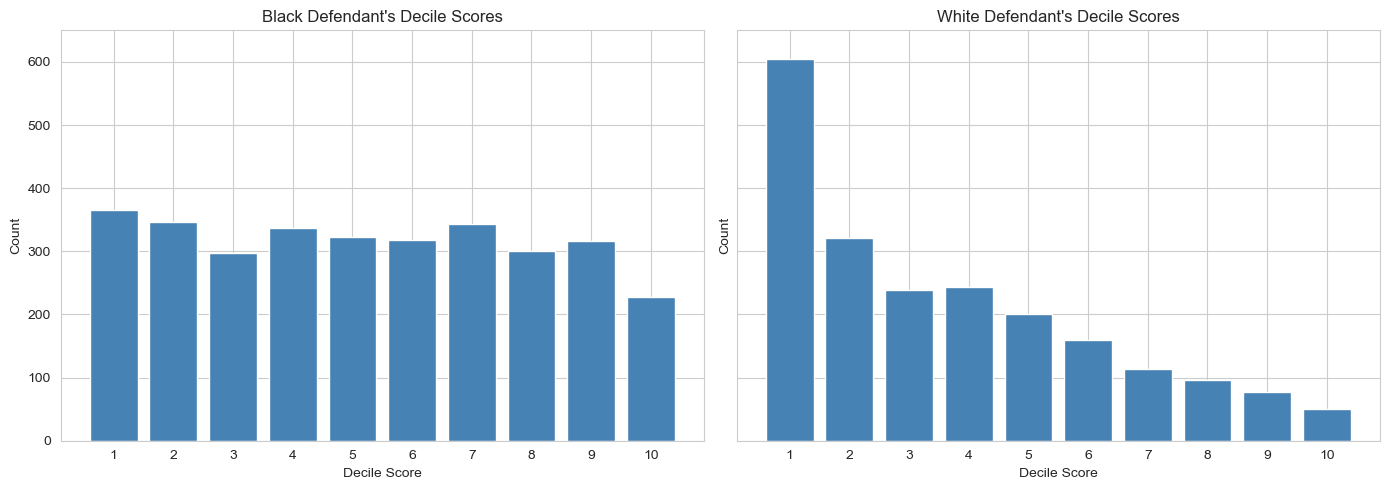

In [11]:
# Reproduce the R side-by-side bar charts:
#   pblack <- ggplot(data=filter(df, race=="African-American"), aes(ordered(decile_score))) + geom_bar()
#   pwhite <- ggplot(data=filter(df, race=="Caucasian"), aes(ordered(decile_score))) + geom_bar()
#   grid.arrange(pblack, pwhite, ncol = 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (race, title) in zip(
    axes,
    [
        ("African-American", "Black Defendant's Decile Scores"),
        ("Caucasian", "White Defendant's Decile Scores"),
    ],
):
    subset = df[df["race"] == race]
    counts = subset["decile_score"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Decile Score")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_ylim(0, 650)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

The distribution for Black defendants is relatively flat across all decile scores, while White defendants are heavily concentrated in the lower scores. This visual disparity motivates the formal statistical testing below.

### 2.5 Score distribution by category (all races)

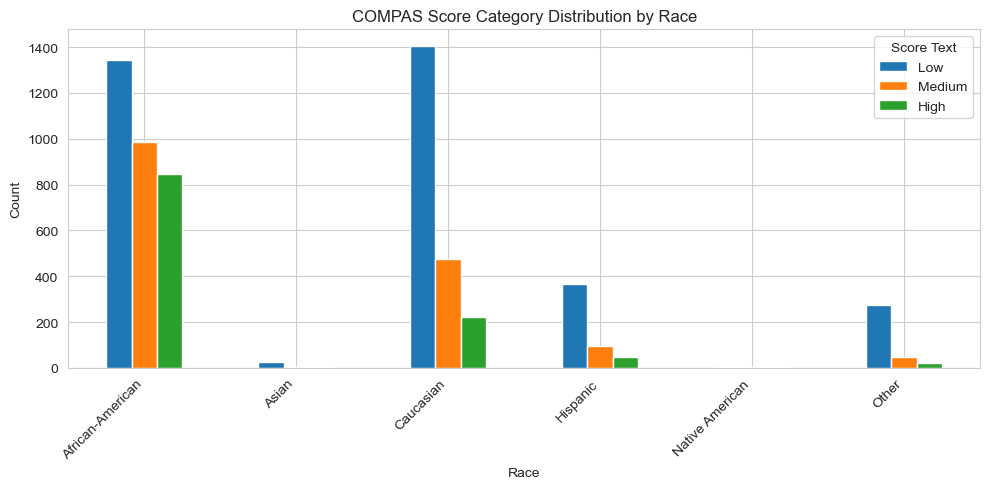

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
score_order = ["Low", "Medium", "High"]
score_counts = df.groupby(["race", "score_text"]).size().unstack(fill_value=0)
score_counts = score_counts.reindex(columns=score_order)
score_counts.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_xlabel("Race")
ax.set_ylabel("Count")
ax.set_title("COMPAS Score Category Distribution by Race")
ax.legend(title="Score Text")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 2.6 Recidivism rates by race and score level

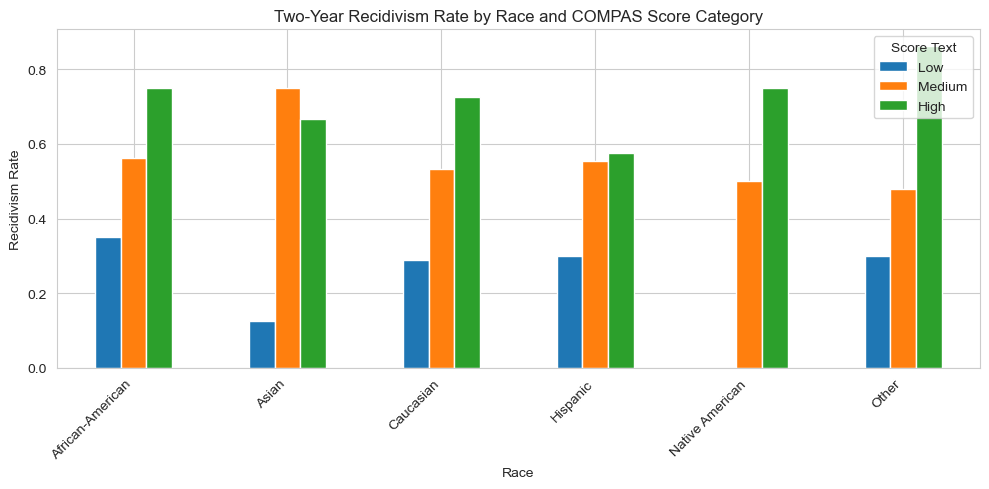

In [13]:
recid_by_race_score = (
    df.groupby(["race", "score_text"])["two_year_recid"]
    .mean()
    .unstack(fill_value=0)
    .reindex(columns=score_order)
)

fig, ax = plt.subplots(figsize=(10, 5))
recid_by_race_score.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_xlabel("Race")
ax.set_ylabel("Recidivism Rate")
ax.set_title("Two-Year Recidivism Rate by Race and COMPAS Score Category")
ax.legend(title="Score Text")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 3. Logistic Regression Model Development

We reproduce the logistic regression from the R script:  
`score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid`

Using `statsmodels` GLM with a binomial family and logit link to obtain coefficient summaries comparable to R's `glm()` output.

In [14]:
# Create a binary numeric outcome (0/1) from the score_factor for the GLM.
# HighScore = 1 (Medium or High COMPAS score), LowScore = 0
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Build the logistic regression formula.
# R equivalent:
#   glm(score_factor ~ gender_factor + age_factor + race_factor +
#       priors_count + crime_factor + two_year_recid,
#       data = df, family = binomial(link = "logit"))
#
# In statsmodels, C(..., Treatment(reference=...)) sets the reference level,
# mirroring R's relevel() function.
formula = (
    "score_binary ~ C(gender_factor, Treatment(reference='Male'))"
    " + C(age_factor, Treatment(reference='25 - 45'))"
    " + C(race_factor, Treatment(reference='Caucasian'))"
    " + priors_count"
    " + C(crime_factor)"
    " + two_year_recid"
)

# Fit the GLM with Binomial family and logit link
model_glm = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
).fit()

# Display full model summary (comparable to R's summary(model_glm))
print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Sun, 29 Mar 2026   Deviance:                       6168.4
Time:                        00:08:07   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

### 3.1 Interpreting key coefficients via odds ratios

The R notebook computes the relative likelihood that Black vs. White defendants receive a higher score. We replicate the same calculation.

In [15]:
# Extract model coefficients for odds ratio calculations.
# This replicates the R notebook's approach:
#   control <- exp(intercept) / (1 + exp(intercept))
#   exp(coef) / (1 - control + (control * exp(coef)))
params = model_glm.params
intercept = params["Intercept"]
control = np.exp(intercept) / (1 + np.exp(intercept))

# Extract specific coefficients of interest
race_aa_coef = params[
    "C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"
]
gender_female_coef = params[
    "C(gender_factor, Treatment(reference='Male'))[T.Female]"
]
age_lt25_coef = params[
    "C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"
]

def relative_likelihood(coef, control_prob):
    """Compute the relative likelihood of receiving a higher score,
    using the same formula as the R notebook."""
    return np.exp(coef) / (1 - control_prob + control_prob * np.exp(coef))

# R expected values: ~1.45 (race), ~1.19 (gender), ~2.50 (age)
print("Relative likelihoods of receiving a higher COMPAS score:")
print(f"  Black vs. White defendants:      {relative_likelihood(race_aa_coef, control):.6f}")
print(f"  Female vs. Male defendants:       {relative_likelihood(gender_female_coef, control):.6f}")
print(f"  Under-25 vs. 25-45 defendants:    {relative_likelihood(age_lt25_coef, control):.6f}")

Relative likelihoods of receiving a higher COMPAS score:
  Black vs. White defendants:      1.452837
  Female vs. Male defendants:       1.194795
  Under-25 vs. 25-45 defendants:    2.496120


Black defendants are roughly 45% more likely than White defendants to receive a higher score, correcting for the seriousness of their crime, previous arrests, and future criminal behavior. This matches the R analysis.

---
## 3b. Violent Recidivism Risk Score Analysis

The source R notebook also analyses the **violent recidivism** COMPAS score using a separate dataset.
This section reproduces that workflow in Python.

R source comment: *"Compas also offers a score that aims to measure a persons risk of violent recidivism,
which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic
regression to test for racial bias."
*

### 3b.1 Load and filter the violent-recidivism dataset

In [16]:
# Load the violent-recidivism raw data from the ProPublica GitHub repository.
# R equivalent: raw_data <- read.csv("./compas-scores-two-years-violent.csv")
url_v = (
    "https://raw.githubusercontent.com/propublica/"
    "compas-analysis/master/compas-scores-two-years-violent.csv"
)
raw_data_v = pd.read_csv(url_v)
print(f"Raw violent records: {len(raw_data_v)}")  # Expects 4,743

Raw violent records: 4743


In [17]:
# Select columns and apply the same four filtering rules used for the general analysis,
# except the score column is now v_score_text (violent).
# R equivalent:
#   df <- dplyr::select(raw_data, age, c_charge_degree, race, age_cat, v_score_text, sex,
#                       priors_count, days_b_screening_arrest, v_decile_score,
#                       is_recid, two_year_recid) %>%
#           filter(days_b_screening_arrest <= 30) %>%
#           filter(days_b_screening_arrest >= -30) %>%
#           filter(is_recid != -1) %>%
#           filter(c_charge_degree != "O") %>%
#           filter(v_score_text != 'N/A')
cols_v = [
    "age", "c_charge_degree", "race", "age_cat", "v_score_text",
    "sex", "priors_count", "days_b_screening_arrest",
    "v_decile_score", "is_recid", "two_year_recid",
]
dfv = raw_data_v[cols_v].copy()

dfv = dfv[
    (dfv["days_b_screening_arrest"] >= -30)
    & (dfv["days_b_screening_arrest"] <= 30)
    & (dfv["is_recid"] != -1)
    & (dfv["c_charge_degree"] != "O")
    & (dfv["v_score_text"] != "N/A")
].copy()

print(f"Filtered violent records: {len(dfv)}  (expected ~4,020)")

Filtered violent records: 4020  (expected ~4,020)


### 3b.2 Violent cohort — descriptive statistics

In [18]:
# R equivalents: summary(df$age_cat), summary(df$race), summary(df$v_score_text)
print("Age category breakdown (violent cohort):")
print(dfv["age_cat"].value_counts().sort_index())

print("\nRace breakdown (violent cohort):")
print(dfv["race"].value_counts())

print("\nViolent score text breakdown:")
print(dfv["v_score_text"].value_counts())

Age category breakdown (violent cohort):
age_cat
25 - 45            2300
Greater than 45     954
Less than 25        766
Name: count, dtype: int64

Race breakdown (violent cohort):
race
African-American    1918
Caucasian           1459
Hispanic             355
Other                255
Asian                 26
Native American        7
Name: count, dtype: int64

Violent score text breakdown:
v_score_text
Low       2913
Medium     828
High       279
Name: count, dtype: int64


In [19]:
# Two-year recidivism count and rate within the violent cohort.
# R equivalents:
#   nrow(filter(df, two_year_recid == 1))          -> 652
#   nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100  -> 16.21891
nv = len(dfv)
recid_v = dfv["two_year_recid"].sum()
print(f"Two-year recidivists (violent cohort): {recid_v}  (expected 652)")
print(f"Recidivism rate: {recid_v / nv * 100:.5f}%  (expected 16.21891%)")

Two-year recidivists (violent cohort): 652  (expected 652)
Recidivism rate: 16.21891%  (expected 16.21891%)


### 3b.3 Violent decile score distributions by race

Side-by-side bar charts mirroring the R ggplot charts for the violent score.

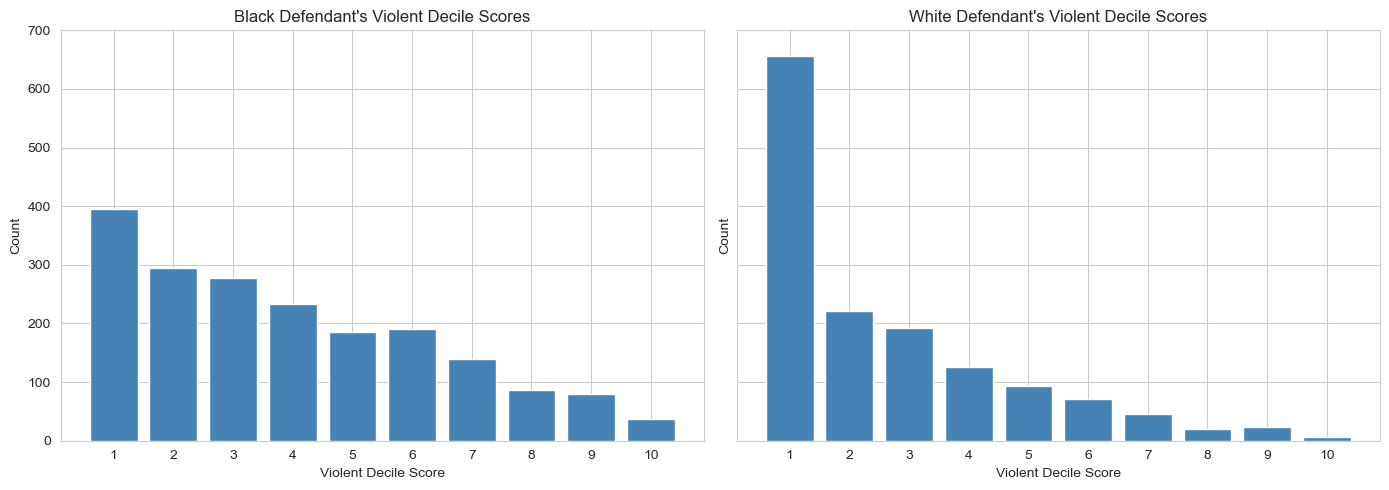

In [20]:
# R equivalent:
#   pblack <- ggplot(data=filter(df, race=="African-American"),
#                    aes(ordered(v_decile_score))) + geom_bar() +
#             xlab("Violent Decile Score") + ylim(0, 700) +
#             ggtitle("Black Defendant's Violent Decile Scores")
#   pwhite <- ggplot(data=filter(df, race=="Caucasian"), ...) + ...
#   grid.arrange(pblack, pwhite, ncol = 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (race, title) in zip(
    axes,
    [
        ("African-American", "Black Defendant's Violent Decile Scores"),
        ("Caucasian",        "White Defendant's Violent Decile Scores"),
    ],
):
    subset = dfv[dfv["race"] == race]
    counts = subset["v_decile_score"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Violent Decile Score")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_ylim(0, 700)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

### 3b.4 Violent recidivism logistic regression

Same model formula as the general analysis, but the outcome is `score_factor` derived from
`v_score_text` (violent COMPAS category).

In [21]:
# Construct derived factor variables for the violent cohort.
# R equivalent:
#   df <- mutate(df, crime_factor = factor(c_charge_degree)) %>%
#         mutate(age_factor = as.factor(age_cat)) %>%
#         within(age_factor <- relevel(age_factor, ref = 1)) %>%
#         mutate(race_factor = factor(race, labels = c(...))) %>%
#         within(race_factor <- relevel(race_factor, ref = 3)) %>%
#         mutate(gender_factor = factor(sex, labels = c("Female","Male"))) %>%
#         within(gender_factor <- relevel(gender_factor, ref = 2)) %>%
#         mutate(score_factor = factor(v_score_text != "Low", labels = c("LowScore","HighScore")))

dfv["crime_factor"] = pd.Categorical(dfv["c_charge_degree"])
dfv["age_factor"] = pd.Categorical(
    dfv["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"],
)
dfv["race_factor"] = pd.Categorical(
    dfv["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
)
dfv["gender_factor"] = pd.Categorical(dfv["sex"], categories=["Male", "Female"])

# score_factor from v_score_text: "Low" -> LowScore, anything else -> HighScore
dfv["score_binary_v"] = (dfv["v_score_text"] != "Low").astype(int)

# Build and fit the violent logistic regression model
# R equivalent: model <- glm(score_factor ~ gender_factor + age_factor + race_factor +
#                             priors_count + crime_factor + two_year_recid,
#                             family="binomial", data=df)
formula_v = (
    "score_binary_v ~ C(gender_factor, Treatment(reference='Male'))"
    " + C(age_factor, Treatment(reference='25 - 45'))"
    " + C(race_factor, Treatment(reference='Caucasian'))"
    " + priors_count"
    " + C(crime_factor)"
    " + two_year_recid"
)

model_glm_v = smf.glm(
    formula=formula_v,
    data=dfv,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
).fit()

print(model_glm_v.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         score_binary_v   No. Observations:                 4020
Model:                            GLM   Df Residuals:                     4008
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1499.4
Date:                Sun, 29 Mar 2026   Deviance:                       2998.8
Time:                        00:08:08   Pearson chi2:                 3.83e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3502
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

The violent score overpredicts recidivism for Black defendants by approximately 77.3% compared to White defendants.

In [22]:
# Compute relative likelihoods for the violent score model.
# R equivalents:
#   control <- exp(-2.24274) / (1 + exp(-2.24274))
#   exp(0.65893) / (1 - control + (control * exp(0.65893)))  -> 1.773921
#   exp(3.14591) / (1 - control + (control * exp(3.14591)))  -> 7.41424
params_v = model_glm_v.params
intercept_v = params_v["Intercept"]
control_v = np.exp(intercept_v) / (1 + np.exp(intercept_v))

race_aa_v = params_v["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]
age_lt25_v = params_v["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]

print("Violent score — relative likelihoods:")
print(f"  Black vs. White defendants:    {relative_likelihood(race_aa_v, control_v):.6f}  (R: 1.773921)")
print(f"  Under-25 vs. 25-45:            {relative_likelihood(age_lt25_v, control_v):.6f}  (R: 7.41424)")
print()
pct = (relative_likelihood(race_aa_v, control_v) - 1) * 100
print(f"  -> Black defendants are {pct:.1f}% more likely to receive a higher violent COMPAS score.")

Violent score — relative likelihoods:
  Black vs. White defendants:    1.773927  (R: 1.773921)
  Under-25 vs. 25-45:            7.414232  (R: 7.41424)

  -> Black defendants are 77.4% more likely to receive a higher violent COMPAS score.


Defendants under 25 are approximately 7.4 times as likely to receive a higher violent score as middle-aged defendants.

---
## 4. Model Diagnostics — Confusion Matrix and Fairness Metrics

Following the instructor's lecture code (slides 38-41), we generate predicted probabilities from the logistic regression model and construct confusion matrices overall and by race.

### 4.1 Predicted probabilities and binary classifications

In [23]:
# Generate predicted probabilities from the fitted model.
# R equivalent: pred_prob = predict(model_glm, type = "response")
df["pred_prob"] = model_glm.predict(df)

# Classify using a 0.5 threshold.
# R equivalent: pred_class = factor(ifelse(pred_prob >= 0.5, 1, 0), labels = c("No Recid", "Recid"))
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

### 4.2 Overall confusion matrix

In [24]:
# Build the overall confusion matrix using sklearn.
# R equivalent: table(Predicted = df$pred_class, Actual = df$two_year_recid)
actual = df["two_year_recid"].values
predicted = (df["pred_prob"] >= 0.5).astype(int).values

cm = confusion_matrix(actual, predicted, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()
n_total = cm.sum()

print("=" * 40)
print("  Overall Confusion Matrix")
print("=" * 40)
cm_df = pd.DataFrame(
    cm,
    index=["Actual=0", "Actual=1"],
    columns=["Pred=No Recid", "Pred=Recid"],
)
print(cm_df)

# Compute the same overall metrics as the R script (slides 38-39)
print(f"\nAccuracy  : {(TP + TN) / n_total:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

  Overall Confusion Matrix
          Pred=No Recid  Pred=Recid
Actual=0           2653         710
Actual=1            945        1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


### 4.3 Confusion matrix by race

In [25]:
# Compute confusion matrix components for each racial group.
# R equivalent:
#   race_metrics <- df %>% group_by(race) %>% summarise(
#       n = n(), TP = sum(pred == 1 & actual == 1), TN = ..., FP = ..., FN = ...,
#       Accuracy = ..., Precision = ..., Recall = ..., FPR = ..., FNR = ...
#   )

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

def compute_cm_metrics(g):
    """Compute confusion matrix counts for a single group."""
    tp = ((g["pred"] == 1) & (g["actual"] == 1)).sum()
    tn = ((g["pred"] == 0) & (g["actual"] == 0)).sum()
    fp = ((g["pred"] == 1) & (g["actual"] == 0)).sum()
    fn = ((g["pred"] == 0) & (g["actual"] == 1)).sum()
    return pd.Series({"n": len(g), "TP": tp, "TN": tn, "FP": fp, "FN": fn})

race_metrics = (
    df.groupby("race")[["pred", "actual"]]
    .apply(compute_cm_metrics)
    .astype(int)
)

# Derive standard classification metrics per group
race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by group size (descending), matching R's arrange(desc(n))
race_metrics = race_metrics.sort_values("n", ascending=False)

print("=" * 80)
print("  Confusion Matrix Metrics by Race")
print("=" * 80)
print(race_metrics.to_string())

  Confusion Matrix Metrics by Race
                     n    TP    TN   FP   FN  Accuracy  Precision  Recall    FPR    FNR
race                                                                                   
African-American  3175  1373   959  555  288     0.734      0.712   0.827  0.367  0.173
Caucasian         2103   381  1148  133  441     0.727      0.741   0.464  0.104  0.536
Hispanic           509    81   306   14  108     0.760      0.853   0.429  0.044  0.571
Other              343    22   216    3  102     0.694      0.880   0.177  0.014  0.823
Asian               31     2    22    1    6     0.774      0.667   0.250  0.043  0.750
Native American     11     5     2    4    0     0.636      0.556   1.000  0.667  0.000


### 4.4 FPR and FNR disparity table (ProPublica framing)

Compute the difference in False Positive Rate and False Negative Rate for each racial group relative to the Caucasian baseline.

In [26]:
# Compute disparity in FPR and FNR relative to the Caucasian baseline.
# R equivalent:
#   disparity <- race_metrics %>% select(race, n, FPR, FNR) %>% mutate(
#       delta_FPR = round(FPR - FPR[race == "Caucasian"], 3),
#       delta_FNR = round(FNR - FNR[race == "Caucasian"], 3)
#   )
caucasian_fpr = race_metrics.loc["Caucasian", "FPR"]
caucasian_fnr = race_metrics.loc["Caucasian", "FNR"]

disparity = race_metrics[["n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print("=" * 60)
print("  FPR and FNR Disparity by Race")
print("=" * 60)
print(disparity.to_string())

  FPR and FNR Disparity by Race
                     n    FPR    FNR  delta_FPR  delta_FNR
race                                                      
African-American  3175  0.367  0.173      0.263     -0.363
Caucasian         2103  0.104  0.536      0.000      0.000
Hispanic           509  0.044  0.571     -0.060      0.035
Other              343  0.014  0.823     -0.090      0.287
Asian               31  0.043  0.750     -0.061      0.214
Native American     11  0.667  0.000      0.563     -0.536


### 4.5 Visualizing fairness metrics by race

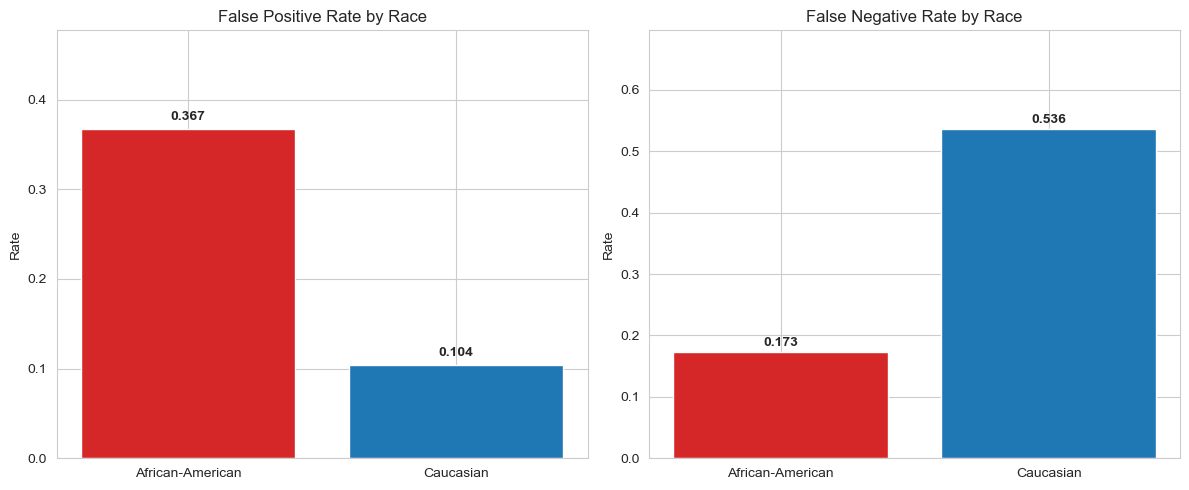

In [27]:
focus = race_metrics.loc[["African-American", "Caucasian"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(focus.index, focus["FPR"], color=["#d62728", "#1f77b4"], edgecolor="white")
axes[0].set_ylabel("Rate")
axes[0].set_title("False Positive Rate by Race")
axes[0].set_ylim(0, max(focus["FPR"]) * 1.3)
for i, v in enumerate(focus["FPR"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(focus.index, focus["FNR"], color=["#d62728", "#1f77b4"], edgecolor="white")
axes[1].set_ylabel("Rate")
axes[1].set_title("False Negative Rate by Race")
axes[1].set_ylim(0, max(focus["FNR"]) * 1.3)
for i, v in enumerate(focus["FNR"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 5. Interpretation and Discussion

### 5.1 Key findings

This Python implementation reproduces the core findings from the ProPublica COMPAS analysis and the instructor's Lecture 01 R workflow:

1. **Racial disparity in score assignment**: The logistic regression confirms that African-American defendants are significantly more likely to be classified as higher risk ("Medium" or "High") compared to Caucasian defendants, even after controlling for age, sex, prior offenses, charge severity, and actual recidivism outcome. The coefficient for `race_factor[African-American]` is positive and highly significant.

2. **Asymmetric error rates**: The confusion matrix analysis by race reveals that the COMPAS-informed logistic model produces:
   - **Higher False Positive Rates (FPR) for Black defendants**: They are more likely to be incorrectly predicted as recidivists when they did not actually recidivate.
   - **Higher False Negative Rates (FNR) for White defendants**: They are more likely to be incorrectly predicted as non-recidivists when they did actually recidivate.

3. **Fairness-accuracy tradeoff**: Even with approximate calibration (similar predicted probabilities for similar risk scores across groups), the model fails to achieve equal error rates across racial groups. This illustrates the impossibility theorem: a risk-assessment tool cannot be simultaneously perfectly calibrated *and* maintain equal FPR/FNR across groups with different base rates.

### 5.2 Connection to the alignment problem

From the lecture's formal framework:

$$\arg\min_{h \in \mathcal{H}} L(h) \neq \arg\max_{h \in \mathcal{H}} U(h)$$

The COMPAS system optimizes predictive accuracy (the proxy loss $L$), but societal utility $U$ includes fairness constraints such as equal error rates across protected groups. The alignment gap $\Delta = U(h^*_U) - U(h^*_L) > 0$ manifests here as the disparity in FPR and FNR between racial groups.

This case study demonstrates that minimizing a training loss does not automatically yield equitable outcomes. Responsible ML requires explicitly incorporating fairness constraints into the optimization, treating alignment as a constrained optimization problem.

### 5.3 Notes on R vs. Python differences

- Coefficient estimates from `statsmodels` GLM match R's `glm()` closely. Minor floating-point differences (typically < 0.001) arise from different numerical optimization implementations (IRLS in R vs. Newton-Raphson in statsmodels).
- Factor reference-level handling differs syntactically: R uses `relevel()`, while Python uses `C(var, Treatment(reference=...))` in the formula API.
- Confusion matrix layout conventions differ: `sklearn` orders by `[negative, positive]` while R's `table()` orders alphabetically. We align the interpretation accordingly.